In [ ]:
# ┌─────────────────────────────────────────┐
# │             Cell 1 (setup)             │
# └─────────────────────────────────────────┘

import numpy as np
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import tensorflow as tf
# 1) Hyperparameters
timesteps = 28      # rows per image
input_dim = 28      # pixels per row
latent_dim = 64     # size of the bottleneck

# 2) Load & preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.
x_train = x_train.reshape(-1, timesteps, input_dim)
x_test  = x_test.reshape(-1, timesteps, input_dim)

# 3) Define shared layers (so we reuse trained weights later)
encoder_inputs = Input(shape=(timesteps, input_dim), name='encoder_input')
encoder_lstm   = LSTM(latent_dim, name='encoder_lstm')
decoder_repeat = RepeatVector(timesteps, name='decoder_repeat')
decoder_lstm   = LSTM(latent_dim, return_sequences=True, name='decoder_lstm')
decoder_dense  = TimeDistributed(Dense(input_dim, activation='sigmoid'), name='decoder_dense') # TimeDistributed applies the same Dense layer to each time step of the sequence

# 4) Wire up the autoencoder
encoded = encoder_lstm(encoder_inputs)                               # → latent vector (64,)
decoded = decoder_dense(decoder_lstm(decoder_repeat(encoded)))       # → sequence (28×28)
autoencoder = Model(encoder_inputs, decoded, name='autoencoder')

# 5) Compile & train
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 6) Extract encoder model
encoder = Model(encoder_inputs, encoded, name='encoder_model')

# 7) Extract decoder model (re-using the SAME layers!)
latent_inputs = Input(shape=(latent_dim,), name='decoder_input')
x = decoder_repeat(latent_inputs)
x = decoder_lstm(x)
x = decoder_dense(x)
decoder = Model(latent_inputs, x, name='decoder_model')


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.4005 - val_loss: 0.2937
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.2918 - val_loss: 0.2827
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.2793 - val_loss: 0.2712
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.2613 - val_loss: 0.2424
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.2405 - val_loss: 0.2306
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.2279 - val_loss: 0.2151
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.2133 - val_loss: 0.2054
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2019 - val_loss: 0.1946
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1900 - val_loss: 0.1824
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1796 - val_loss: 0.1733
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1726 - val_loss: 0.1669
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


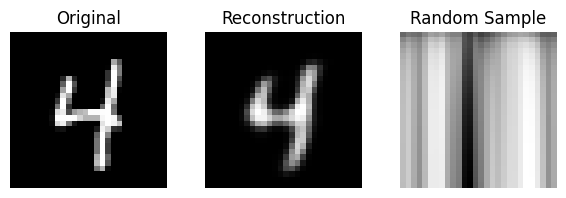

In [5]:
# ┌─────────────────────────────────────────┐
# │      Cell 2 (reconstruct & sample)     │
# └─────────────────────────────────────────┘

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1) (Re)load & preprocess just the test set
(_, _), (x_test, _) = mnist.load_data()
x_test = x_test.astype('float32') / 255.
x_test = x_test.reshape(-1, timesteps, input_dim)

# 2) Pick which test image to reconstruct
idx = int(input(f"Enter test index (0–{len(x_test)-1}): "))

original = x_test[idx]                                    # the true image
encoded_img    = encoder.predict(original[np.newaxis,...])  # → (1, latent_dim)
reconstruction = decoder.predict(encoded_img)[0]            # → (28, 28)

# 3) Sample a brand-new image from random noise
random_latent = np.random.normal(size=(1, latent_dim))
random_img    = decoder.predict(random_latent)[0]           # → (28, 28)

# 4) Plot side by side
plt.figure(figsize=(6,2))

plt.subplot(1,3,1)
plt.title('Original')
plt.imshow(original,    cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Reconstruction')
plt.imshow(reconstruction, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Random Sample')
plt.imshow(random_img,  cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [13]:
np.random.randn(4)

array([ 0.27911995, -0.46296552, -0.38359431, -0.13921756])